<a href="https://www.kaggle.com/code/sonawanelalitsunil/fruit-classification-ml-100?scriptVersionId=272308489" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fruit-classification/fruit_classification_dataset.csv


## Title: 🍎 Fruit Classification

## Description:
The Fruit Classification dataset is designed to train and evaluate machine learning models that can accurately identify different types of fruits based on their visual or numerical features. It typically contains images or attributes such as color, size, shape, and texture, enabling algorithms to distinguish between fruit categories like apples, bananas, oranges, and more.

This dataset is valuable for developing image recognition systems, computer vision applications, and educational projects in data science and artificial intelligence. It can be used to explore feature extraction, data preprocessing, model evaluation, and classification techniques.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/fruit-classification/fruit_classification_dataset.csv")

In [3]:
df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


In [4]:
df.tail()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
9995,3.7,round,49.7,72.7,purple,tangy,plum
9996,2.8,oval,18.1,65.5,red,sweet,strawberry
9997,8.7,oval,177.7,72.2,green,sweet,pear
9998,18.0,round,1165.0,107.0,brown,sweet,coconut
9999,7.2,round,252.1,111.3,red,sweet,pomegranate


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [6]:
df.describe()

,size (cm),weight (g),avg_price (₹)
count,10000.000000,10000.000000,10000.000000
mean,8.430600,455.457720,77.016720
std,6.396915,731.643087,38.946916
min,0.900000,4.500000,9.000000
25%,3.700000,45.800000,45.575000
50%,7.200000,168.800000,75.400000
75%,10.100000,365.275000,100.700000
max,27.500000,3299.800000,165.000000


In [7]:
df.isnull().sum()

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64

In [8]:
df.duplicated().sum()

246

In [9]:
df.nunique()

size (cm)         227
shape               3
weight (g)       4168
avg_price (₹)    1355
color               8
taste               3
fruit_name         20
dtype: int64

In [10]:
df.shape

(10000, 7)

In [11]:
df.dtypes

size (cm)        float64
shape             object
weight (g)       float64
avg_price (₹)    float64
color             object
taste             object
fruit_name        object
dtype: object

In [12]:
df.columns

Index(['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'color', 'taste',
       'fruit_name'],
      dtype='object')

## Data visualizations

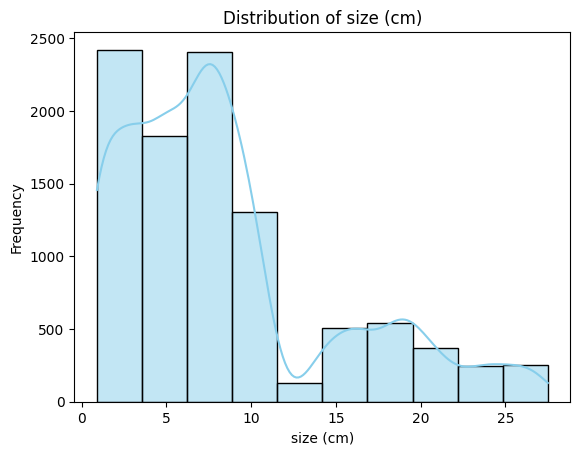

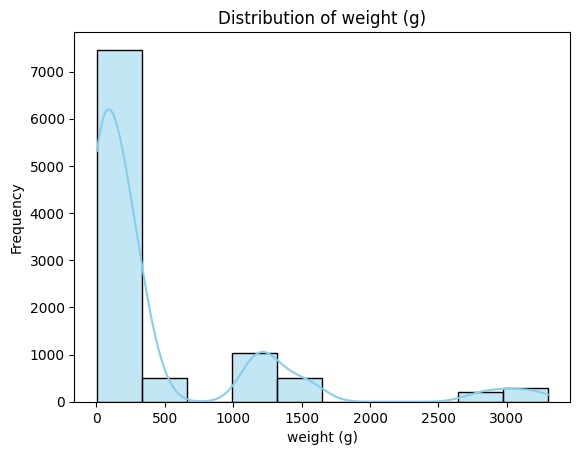

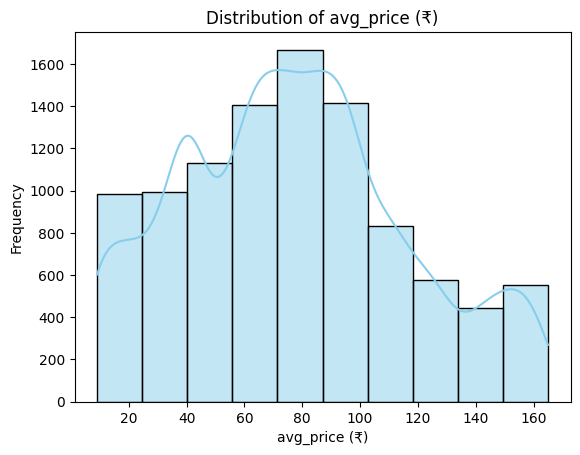

In [13]:
numeric_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], bins=10, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

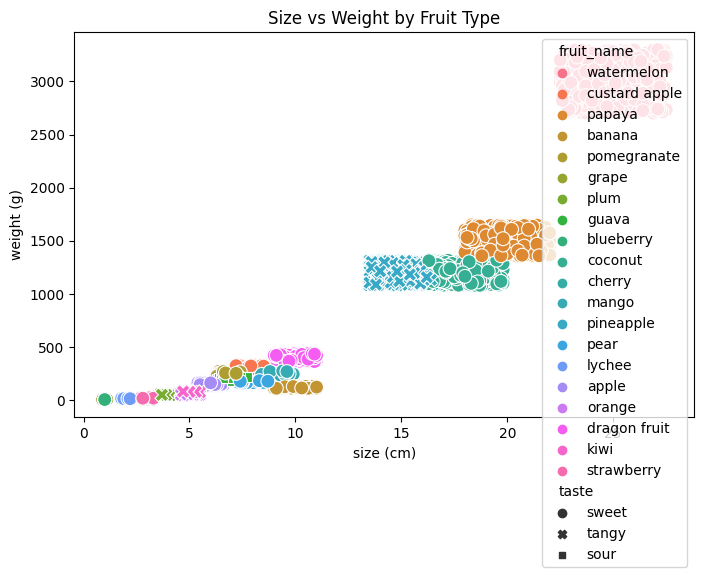

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='size (cm)', y='weight (g)', hue='fruit_name', style='taste', s=100)
plt.title("Size vs Weight by Fruit Type")
plt.show()

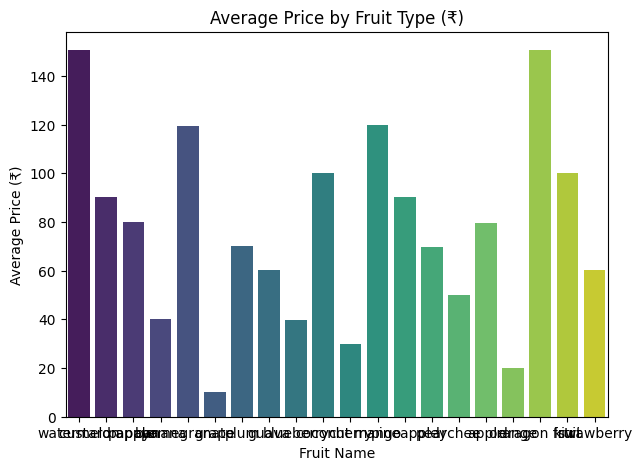

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='fruit_name', y='avg_price (₹)', estimator='mean', ci=None, palette='viridis')
plt.title("Average Price by Fruit Type (₹)")
plt.xlabel("Fruit Name")
plt.ylabel("Average Price (₹)")
plt.show()

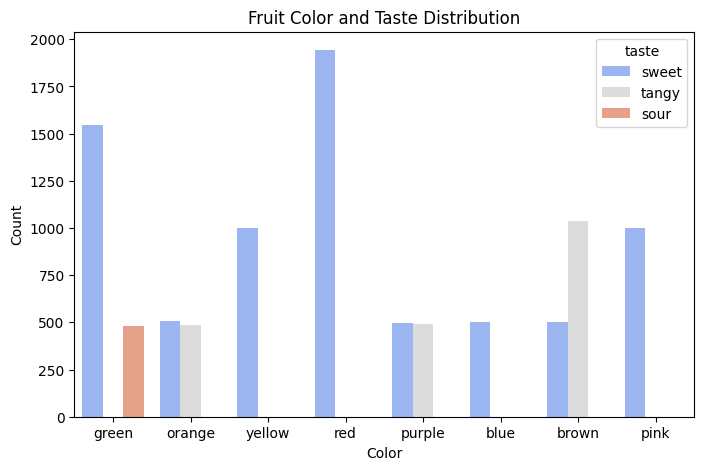

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='color', hue='taste', palette='coolwarm')
plt.title("Fruit Color and Taste Distribution")
plt.xlabel("Color")
plt.ylabel("Count")
plt.show()

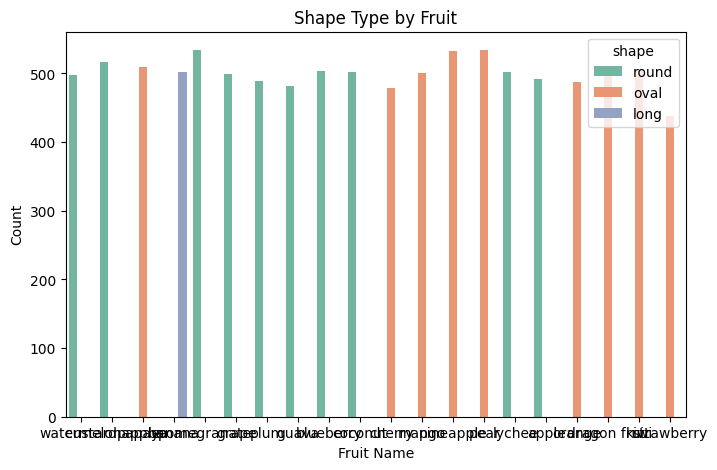

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fruit_name', hue='shape', palette='Set2')
plt.title("Shape Type by Fruit")
plt.xlabel("Fruit Name")
plt.ylabel("Count")
plt.show()

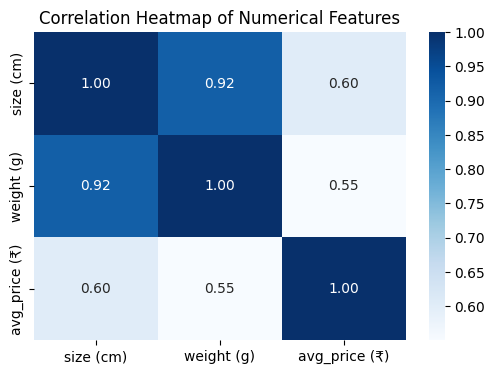

In [18]:
plt.figure(figsize=(6, 4))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## ML Algorithms

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [20]:
label_enc = LabelEncoder()
for col in ['shape', 'color', 'taste', 'fruit_name']:
    df[col] = label_enc.fit_transform(df[col])

In [21]:
X = df[['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'color', 'taste']]
y = df['fruit_name']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [23]:
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_scores[name] = round(acc, 2)
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 97.20%
Decision Tree Accuracy: 100.00%
Random Forest Accuracy: 100.00%
Support Vector Machine Accuracy: 68.50%
K-Nearest Neighbors Accuracy: 98.17%
Gradient Boosting Accuracy: 100.00%


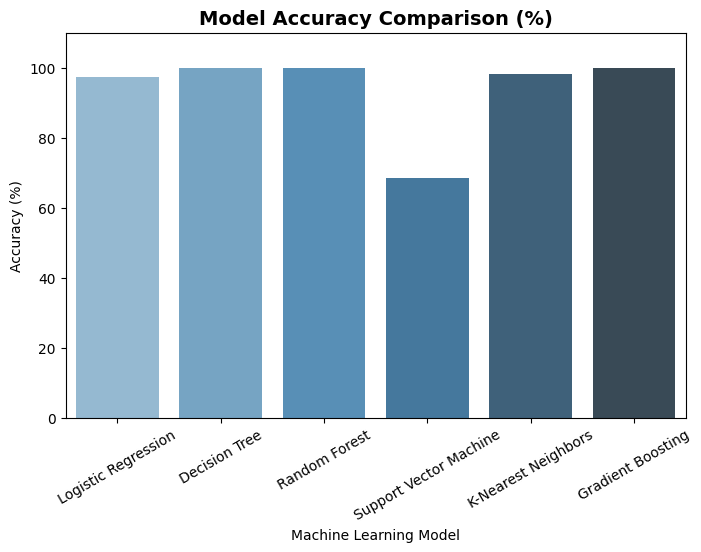

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='Blues_d')
plt.title("Model Accuracy Comparison (%)", fontsize=14, fontweight='bold')
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.ylim(0, 110)
plt.show()

## Thank you...pls upvote!!!!